In [35]:
import cv2
import os
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.engine.results import Boxes

In [31]:
project_root = "/home/wins057/Documents/Projects/python-for-dl-homework/week16"
model_path = f"{project_root}/checkpoints/yolo12l.pt"
image_path = f"{project_root}/images/no_violation/frame_00000.jpg"

In [3]:
def run_yolo_detect_on_image(model_path, image_path, conf_thresh=0.8, display=True):
    """
    Run YOLOv8 object detection (no segmentation) on an image, filtering for vehicle classes.

    Args:
        model_path (str): Path to the YOLOv8 model (.pt).
        image_path (str): Path to the image file.
        conf_thresh (float): Confidence threshold for detections.
        display (bool): If True, show the rendered image with matplotlib.

    Returns:
        result (ultralytics.engine.results.Result): Filtered YOLO result object.
    """
    # Supported vehicle class IDs in COCO: car=2, motorcycle=3, bus=5
    vehicle_class_ids = [2, 3, 5]

    model = YOLO(model_path)
    results = model(image_path)
    result = results[0]

    # Check if any detections exist
    if result.boxes is None or len(result.boxes.cls) == 0:
        print("No detections found.")
        return result

    # Apply filtering: confidence and class
    cls_ids = result.boxes.cls.int().tolist()
    confs = result.boxes.conf
    cls_mask = torch.tensor([cls in vehicle_class_ids for cls in cls_ids], device=confs.device)
    conf_mask = confs > conf_thresh
    combined_mask = cls_mask & conf_mask

    # Replace with filtered Boxes
    result.boxes = Boxes(
        boxes=result.boxes.data[combined_mask],
        orig_shape=result.orig_shape
    )

    # Optional display
    if display:
        rendered = result.plot()
        rendered_rgb = cv2.cvtColor(rendered, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(rendered_rgb)
        plt.axis("off")
        plt.title("YOLOv8 Filtered: Vehicles Only (conf > 0.8)")
        plt.show()

    return result

In [4]:
def extract_padded_crops(result, original_image, pad_percent=0.2):
    """
    Extract padded crops from the original image using bounding boxes in the YOLO result.

    Args:
        result (ultralytics.engine.results.Result): YOLO detection result (filtered).
        original_image (np.ndarray): The original input image (BGR).
        pad_percent (float): Percentage padding to extend around each box (default: 0.2 = 20%).

    Returns:
        List[np.ndarray]: List of cropped image regions with padding applied.
    """
    h_img, w_img = original_image.shape[:2]
    crops = []

    for box in result.boxes.xyxy:
        x1, y1, x2, y2 = map(int, box.cpu().numpy())
        w = x2 - x1
        h = y2 - y1

        # Calculate padding
        pad_x = int(w * pad_percent)
        pad_y = int(h * pad_percent)

        # Apply padding and clip to image bounds
        x1p = max(0, x1 - pad_x)
        y1p = max(0, y1 - pad_y)
        x2p = min(w_img, x2 + pad_x)
        y2p = min(h_img, y2 + pad_y)

        # Crop image
        crop = original_image[y1p:y2p, x1p:x2p]
        crops.append(crop)

    return crops

In [32]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import torch
import cv2

def vlm_check_red_line_violation(crops, resize_to=(224, 224), device="cuda"):
    # Load better, lightweight model
    processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl")
    model = Blip2ForConditionalGeneration.from_pretrained(
        "Salesforce/blip2-flan-t5-xl",
        torch_dtype=torch.float16
    ).to("cuda")
    model.eval()

    responses = []

    for idx, crop in enumerate(crops):
        # Convert OpenCV BGR to PIL RGB and resize
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(crop_rgb).resize(resize_to)

        # Specific prompt for accurate answers
        question = "Answer 'yes' or 'no': The vehicle is parked on or touching a red no-parking line."

        # Process input and run inference
        inputs = processor(pil_img, question, return_tensors="pt").to(device)
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=10)
        answer = processor.decode(output[0], skip_special_tokens=True).strip().lower()

        print(f"[Crop #{idx}] VLM Answer: {answer}")
        responses.append({
            "crop_id": idx,
            "answer": answer
        })

    return responses

In [25]:
import torch
torch.cuda.empty_cache()


image 1/1 /home/wins057/Documents/Projects/python-for-dl-homework/week16/images/no_violation/frame_00000.jpg: 384x640 1 person, 5 cars, 2 motorcycles, 1 truck, 9.1ms
Speed: 0.7ms preprocess, 9.1ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Crop #0: shape = (123, 182, 3)


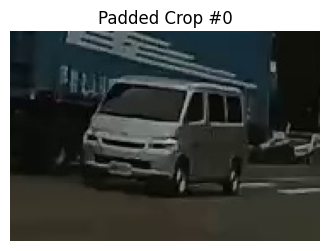

Crop #1: shape = (65, 91, 3)


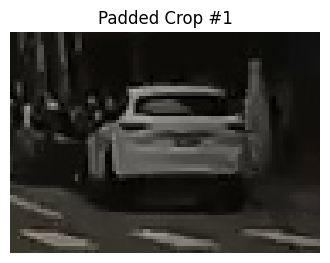

In [ ]:
# 1. Get result and original image
result = run_yolo_detect_on_image(model_path, image_path, conf_thresh=0.7, display=False)
img = cv2.imread(image_path)

# 2. Get padded crops
padded_crops = extract_padded_crops(result, img, pad_percent=0.4)

def save_unlabeled_crops(crops, save_dir=f"{project_root}/dataset"):
    os.makedirs(save_dir, exist_ok=True)
    for idx, crop in enumerate(crops):
        save_path = os.path.join(save_dir, f"crop_{idx:04}.jpg")
        cv2.imwrite(save_path, crop)
        print(f"[Saved] {save_path}")

# 3. Visualize the first crop
for idx, crop in enumerate(padded_crops):
    print(f"Crop #{idx}: shape = {crop.shape}")

    # Optional: visualize
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Padded Crop #{idx}")
    plt.show()

In [8]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-flan-t5-xl",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

image = Image.open("/home/wins057/Documents/Projects/python-for-dl-homework/week16/dataset/image/no_violations/B1021114/frame_00000.jpg").convert("RGB")
question = "Is the car parked on a red line that indicates a no-parking zone?"

inputs = processor(image, question, return_tensors="pt").to("cuda")
out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True))

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.86it/s]


yes
